## Pandas analysis

This exercise consists in analyzing a dataset containg timing information from a series of Time-to-Digital-Converters (TDC) implemented in a couple of FPGAs. Each measurement (i.e. each row of the input file) consists of a flag that specifies the type of message ('HEAD', which in this case is always 1), two addresses of the TDC providing the signal ('FPGA' and 'TDC_CHANNEL'), and the timing information ('ORBIT_CNT', 'BX_COUNTER', and 'TDC_MEAS'). Each TDC count corresponds to 25/30 ns, whereas a unit of BX_COUNTER corresponds to 25 ns, and the ORBIT_CNT is increased every 'x' BX_COUNTER. This allows to store the time in a similar way to hours, minutes and seconds.

Time do Digital converters:
FPGA
flag to identify type of message: HEAD = 1
FPGA and TDC_CHANNEL indicates the adress of signal
TDC_MEAS = 25/30ns
BX_COUNTER = 25ns
ORBIT_CNT increases every x BX_COUNTER


In [3]:
!pip install wget

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9711 sha256=32eed1555316fd484f1e65a8e7ba121feab945cdf88b53c6ffe307d0b080d585
  Stored in directory: c:\users\melis\appdata\local\pip\cache\wheels\40\b3\0f\a40dbd1c6861731779f62cc4babcb234387e11d697df70ee97
Successfully built wget


In [4]:
import wget

In [5]:
# If you didn't download it yet, please get the relevant file now!
url ='https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt?dl=1'

In [6]:
dataset = wget.download(url)

100% [........................................................................] 33179236 / 33179236

In [2]:
import urllib.request
import os

os.makedirs('data1', exist_ok=True)

url_data = 'https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt?dl=1'
urllib.request.urlretrieve(url_data, 'data1/data_000637.txt')

('data1/data_000637.txt', <http.client.HTTPMessage at 0x25c8d8dbfd0>)

1\. Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.

2\. Find out the number of BX in a ORBIT (the value 'x').

3\. Find out how much the data taking lasted. You can either make an estimate based on the fraction of the measurements (rows) you read, or perform this check precisely by reading out the whole dataset.

4\. Create a new column with the absolute time in ns (as a combination of the other three columns with timing information).

5\. Replace the values (all 1) of the HEAD column randomly with 0 or 1.

6\. Create a new DataFrame that contains only the rows with HEAD=1.

7\. Make two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel

8\. Use the groupby method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3)

9\. Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139

In [2]:
import pandas as pd
import numpy as np

In [8]:
dataframe = pd.read_csv(dataset,nrows=10500)

In [10]:
dataframe.head(30)

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS
0,1,0,123,3869200167,2374,26
1,1,0,124,3869200167,2374,27
2,1,0,63,3869200167,2553,28
3,1,0,64,3869200167,2558,19
4,1,0,64,3869200167,2760,25
5,1,0,63,3869200167,2762,4
6,1,0,61,3869200167,2772,14
7,1,0,139,3869200167,2776,0
8,1,0,62,3869200167,2774,21
9,1,0,60,3869200167,2788,7


In [12]:
#1. Create a Pandas DataFrame re2ading N rows of the 'data_000637.txt' dataset.
#Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.
len(df)

1310720

In [18]:
numbx = dataframe.groupby('ORBIT_CNT')['BX_COUNTER'].nunique()
numbx.head(30)

ORBIT_CNT
3869200167     34
3869200168     68
3869200169     95
3869200170     80
3869200171     83
3869200172     78
3869200173     79
3869200174    101
3869200175     92
3869200176     41
3869200177     78
3869200178     71
3869200179     82
3869200180     66
3869200181     76
3869200182     44
3869200183     95
3869200184     53
3869200185    108
3869200186     70
3869200187     77
3869200188     84
3869200189     33
3869200190     72
3869200191    113
3869200192     57
3869200193    101
3869200194     98
3869200195     63
3869200196     48
Name: BX_COUNTER, dtype: int64

In [19]:
num_teste = dataframe.groupby('ORBIT_CNT')['BX_COUNTER'].transform('nunique')
num_teste.head(30)

0     34
1     34
2     34
3     34
4     34
5     34
6     34
7     34
8     34
9     34
10    34
11    34
12    34
13    34
14    34
15    34
16    34
17    34
18    34
19    34
20    34
21    34
22    34
23    34
24    34
25    34
26    34
27    34
28    34
29    34
Name: BX_COUNTER, dtype: int64

In [18]:
#2. Find out the number of BX in a ORBIT (the value 'x')
df_bx =  df.groupby('ORBIT_CNT')['BX_COUNTER'].nunique()
df_bx.head(30)

ORBIT_CNT
3869200167     34
3869200168     68
3869200169     95
3869200170     80
3869200171     83
3869200172     78
3869200173     79
3869200174    101
3869200175     92
3869200176     41
3869200177     78
3869200178     71
3869200179     82
3869200180     66
3869200181     76
3869200182     44
3869200183     95
3869200184     53
3869200185    108
3869200186     70
3869200187     77
3869200188     84
3869200189     33
3869200190     72
3869200191    113
3869200192     57
3869200193    101
3869200194     98
3869200195     63
3869200196     48
Name: BX_COUNTER, dtype: int64

In [20]:
#3. Find out how much the data taking lasted. You can either make an estimate based on the fraction of the measurements (rows) 
#you read, or perform this check precisely by reading out the whole dataset.
df['timens']=df['TDC_MEAS']*25/30+df['BX_COUNTER']*25
df.head(10)

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,bx,timens
0,1,0,123,3869200167,2374,26,NaN,59371.666667
1,1,0,124,3869200167,2374,27,NaN,59372.500000
2,1,0,63,3869200167,2553,28,NaN,63848.333333
3,1,0,64,3869200167,2558,19,NaN,63965.833333
4,1,0,64,3869200167,2760,25,NaN,69020.833333
5,1,0,63,3869200167,2762,4,NaN,69053.333333
6,1,0,61,3869200167,2772,14,NaN,69311.666667
7,1,0,139,3869200167,2776,0,NaN,69400.000000
8,1,0,62,3869200167,2774,21,NaN,69367.500000
9,1,0,60,3869200167,2788,7,NaN,69705.833333


In [21]:
dataframe['ABSOLUTE_TIME'] = ((dataframe.groupby('ORBIT_CNT')['BX_COUNTER'].transform('nunique'))*25
                            + dataframe['BX_COUNTER'] * 25
                            + dataframe['TDC_MEAS'] * 25)
dataframe.head(30)

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,ABSOLUTE_TIME
0,1,0,123,3869200167,2374,26,60850
1,1,0,124,3869200167,2374,27,60875
2,1,0,63,3869200167,2553,28,65375
3,1,0,64,3869200167,2558,19,65275
4,1,0,64,3869200167,2760,25,70475
5,1,0,63,3869200167,2762,4,70000
6,1,0,61,3869200167,2772,14,70500
7,1,0,139,3869200167,2776,0,70250
8,1,0,62,3869200167,2774,21,70725
9,1,0,60,3869200167,2788,7,70725


In [26]:
#4. Create a new column with the absolute time in ns (as a combination of the other three columns with timing information).
df['ABS_TIMENS'] = (
    (df.groupby('ORBIT_CNT')['BX_COUNTER']
      .transform('nunique')) * 25
    + df['BX_COUNTER'] * 25
    + df['TDC_MEAS'] * 25 / 30
)
print(df['ABS_TIMENS'])

0        60221.666667
1        60222.500000
2        64698.333333
3        64815.833333
4        69870.833333
             ...     
14995    86632.500000
14996    86662.500000
14997    89913.333333
14998    89990.000000
14999    90125.000000
Name: ABS_TIMENS, Length: 15000, dtype: float64


In [30]:
del df['bx']
df.head(50)

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,timens,ABS_TIMENS
0,1,0,123,3869200167,2374,26,59371.666667,60221.666667
1,1,0,124,3869200167,2374,27,59372.500000,60222.500000
2,1,0,63,3869200167,2553,28,63848.333333,64698.333333
3,1,0,64,3869200167,2558,19,63965.833333,64815.833333
4,1,0,64,3869200167,2760,25,69020.833333,69870.833333
5,1,0,63,3869200167,2762,4,69053.333333,69903.333333
6,1,0,61,3869200167,2772,14,69311.666667,70161.666667
7,1,0,139,3869200167,2776,0,69400.000000,70250.000000
8,1,0,62,3869200167,2774,21,69367.500000,70217.500000
9,1,0,60,3869200167,2788,7,69705.833333,70555.833333


In [32]:
#5. Replace the values (all 1) of the HEAD column randomly with 0 or 1.
df.loc[df['HEAD'] == 1, 'HEAD'] = np.random.choice([0, 1], size=(df['HEAD'] == 1).sum())


In [28]:
dataframe.loc[dataframe['HEAD'] == 1,'HEAD'] = np.random.choice([0,1], size = len(dataframe['HEAD']))

In [31]:
dataframe.head(10)

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,ABSOLUTE_TIME
0,1,0,123,3869200167,2374,26,60850
1,0,0,124,3869200167,2374,27,60875
2,1,0,63,3869200167,2553,28,65375
3,1,0,64,3869200167,2558,19,65275
4,0,0,64,3869200167,2760,25,70475
5,1,0,63,3869200167,2762,4,70000
6,0,0,61,3869200167,2772,14,70500
7,1,0,139,3869200167,2776,0,70250
8,0,0,62,3869200167,2774,21,70725
9,1,0,60,3869200167,2788,7,70725


In [42]:
#6. Create a new DataFrame that contains only the rows with HEAD=1.

df_one = df.loc[df['HEAD'] == 1] 
df_one.head(10)

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,timens,ABS_TIMENS
1,1,0,124,3869200167,2374,27,59372.500000,60222.500000
2,1,0,63,3869200167,2553,28,63848.333333,64698.333333
3,1,0,64,3869200167,2558,19,63965.833333,64815.833333
4,1,0,64,3869200167,2760,25,69020.833333,69870.833333
6,1,0,61,3869200167,2772,14,69311.666667,70161.666667
10,1,1,7,3869200167,2785,4,69628.333333,70478.333333
12,1,1,6,3869200167,2792,18,69815.000000,70665.000000
13,1,0,36,3869200167,2791,23,69794.166667,70644.166667
15,1,1,139,3869200167,2797,0,69925.000000,70775.000000
16,1,1,8,3869200167,2787,14,69686.666667,70536.666667


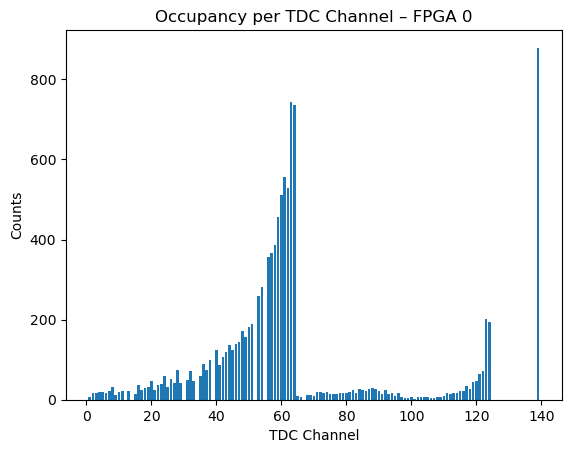

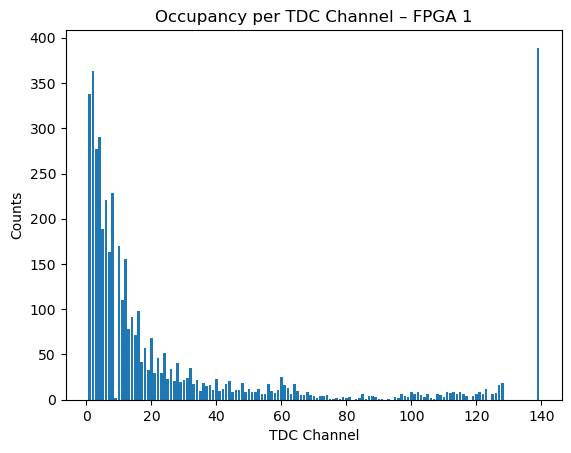

In [70]:
#7. Make two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel
#occupancy = numero de linhas, nao valor fisico
import matplotlib.pyplot as plt
occ = (df.groupby(['FPGA', 'TDC_CHANNEL']).size().reset_index(name='COUNTS'))
occ_fpga0 = occ[occ['FPGA'] == 0]
occ_fpga1 = occ[occ['FPGA'] == 1]

plt.figure()
plt.bar(occ_fpga0['TDC_CHANNEL'], occ_fpga0['COUNTS'])
plt.xlabel('TDC Channel')
plt.ylabel('Counts')
plt.title('Occupancy per TDC Channel – FPGA 0')
plt.show()

plt.figure()
plt.bar(occ_fpga1['TDC_CHANNEL'], occ_fpga1['COUNTS'])
plt.xlabel('TDC Channel')
plt.ylabel('Counts')
plt.title('Occupancy per TDC Channel – FPGA 1')
plt.show()

In [90]:
#8. Use the groupby method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3)
df_noise = (df.groupby(['TDC_CHANNEL']).size().reset_index(name='COUNT').sort_values(by='COUNT', ascending=False))
df_noise.head(3)

,TDC_CHANNEL,COUNT
128,139,1268
63,64,752
62,63,749


In [98]:
#9. Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139
n_orbit = df['ORBIT_CNT'].nunique()
print(n_orbit)
n_orbits_139 = df.loc[df['TDC_CHANNEL'] == 139, 'ORBIT_CNT'].nunique()
print(n_orbits_139)

150
150


In [112]:
df_x = df.loc[df['TDC_CHANNEL'] == 139]
df_x.head(30)

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,timens,ABS_TIMENS
7,0,0,139,3869200167,2776,0,69400.0,70250.0
15,1,1,139,3869200167,2797,0,69925.0,70775.0
30,1,0,139,3869200167,3085,0,77125.0,77975.0
39,1,0,139,3869200167,3186,0,79650.0,80500.0
48,1,0,139,3869200168,23,0,575.0,2275.0
56,1,1,139,3869200168,272,0,6800.0,8500.0
86,1,0,139,3869200168,1505,0,37625.0,39325.0
88,1,1,139,3869200168,1505,0,37625.0,39325.0
99,1,0,139,3869200168,1616,0,40400.0,42100.0
106,0,0,139,3869200168,1675,0,41875.0,43575.0
